## Gradient data with Peltier on one side and RT on other

note: it was difficult to keep the RT side consistent, so analysis tries to take temperature gaps into account as well as whether the battery was heating or cooling

In [1]:
import sys
sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/ultrasonicTesting')

import pickleJar as pj
import sqliteUtils as squ
import numpy as np
from numpy import fft
import os.path
import matplotlib.pyplot as plt

In [3]:
# First we load the data from the file we want to analyze
# The experiment should always output sqlite3 files, so let's convert them to a more usable pickle form first
sqliteFile = "/Users/xz498/Desktop/ultrasound project/data analysis/gradient_data/fatima_pouch_cell_transmission_gradient_RT_301774365299.sqlite3"

# Convert the sqlite3 to a .pickle
# This takes a few seconds. A progress bar will display in your terminal
pj.sqliteToPickle(sqliteFile)

# Load the pickle
pickleFile = os.path.splitext(sqliteFile)[0] + '.pickle'

sqliteToPickle Warning: pickle file /Users/xz498/Desktop/ultrasound project/data analysis/gradient_data/fatima_pouch_cell_transmission_gradient_RT_301774365299.pickle already exists. Conversion aborted.


In [3]:
data = pj.loadPickle("/Users/xz498/Desktop/ultrasound project/data analysis/gradient_data/fatima_pouch_cell_transmission_gradient_RT_301774365299.pickle")

In [ ]:
# for k, v in data.items():
#         print("key:",k, "type:", type(v))
#         if isinstance(v, dict):
#             for k2, v2 in v.items():
#                 print("\tkey:",k2, "type:", type(v2))

In [5]:
## Very slow on laptop
# import plotly.graph_objects as go
# from ipywidgets import interact
# import ipywidgets as widgets
# from datetime import datetime
# import matplotlib.cm as cm

# def plot_waveform(i):
#     fig = go.Figure()
#     fig.add_trace(go.Scatter(x=data[i]['time'], y=data[i]['voltage'], mode='lines'))
#     fig.update_layout(
#         title=f'Measurement {i} at ({datetime.fromtimestamp(data[i]["time_collected"]).strftime("%Y-%m-%d, %H:%M:%S")})',
#         xaxis_title='Time (ns)',
#         yaxis_title='Voltage (mV)'
#     )
#     fig.show()

# # slider = widgets.IntSlider(
# #     value=0,
# #     min=0,
# #     max=len(data) - 2,
# #     step=1,
# #     description='measurement:',
# #     continuous_update=False
# # )

# # interact(plot_waveform, i=slider)

In [ ]:
import plotly.graph_objects as go
# from ipywidgets import interact
# import ipywidgets as widgets
# from datetime import datetime
# import matplotlib.cm as cm

# def plot_waveform(i):
#     fig = go.Figure()
#     fig.add_trace(go.Scatter(x=data[i]['time'], y=data[i]['voltage'], mode='lines'))
#     fig.update_layout(
#         title=f'Measurement {i} at ({datetime.fromtimestamp(data[i]["time_collected"]).strftime("%Y-%m-%d, %H:%M:%S")})',
#         xaxis_title='Time (ns)',
#         yaxis_title='Voltage (mV)'
#     )
#     fig.show()

# # slider = widgets.IntSlider(
# #     value=0,
# #     min=0,
# #     max=len(data) - 2,
# #     step=1,
# #     description='measurement:',
# #     continuous_update=False
# # )

# # interact(plot_waveform, i=slider)

## Merge the waveform and controller data wrt time that UT is running

In [62]:
import pandas as pd
measurements = {k:v for k,v in data.items() if isinstance(k, int)}
waveform_df = pd.DataFrame(measurements).transpose()
# waveform_df['time_collected'] = waveform_df['time_collected'].astype(str)
waveform_df.head()

,voltage,time,time_collected,collection_index
0,"[-1.1445835383858267, -1.0760531496062993, -1....","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1774365342.16086,0.0
1,"[-1.0925799704724408, -1.0278604822834647, -1....","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1774365352.939237,1.0
2,"[-0.9029521407480314, -0.834423597440945, -0.8...","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1774365363.757886,2.0
3,"[-0.7857898622047245, -0.6824126476377952, -0....","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1774365374.566863,3.0
4,"[-0.7067322834645668, -0.6281520669291338, -0....","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1774365385.356689,4.0


In [106]:
len(waveform_df['time_collected'].unique())

333

In [69]:
# waveform_df['time_collected'] = waveform_df['time_collected'].apply(lambda x: datetime.fromtimestamp(x).strftime("%Y-%m-%d, %H:%M:%S"))
# pd.to_datetime(waveform_df['time_collected'])
waveform_df.tail()

,voltage,time,time_collected,collection_index
328,"[-0.2693799212598425, -0.21810716043307088, -0...","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1774368887.189977,328.0
329,"[-0.27369894192913385, -0.21810100885826772, -...","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1774368897.970311,329.0
330,"[-0.2648726624015748, -0.2054478346456693, -0....","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1774368908.758656,330.0
331,"[-0.2764948326771654, -0.2118596210629921, -0....","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1774368919.554558,331.0
332,"[-0.2830837844488189, -0.22624569389763782, -0...","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1774368930.348926,332.0


In [85]:
keep_cols = ['Time', 'Milliseconds',
             '1000.1: CH1 Object', '1000.2: CH2 Object', 
             '1045.1: HR1 Temp', '1045.2: HR2 Temp', 
             '2010.1: Output Enable', '2010.2: Output Enable', 
             '3034.1: Peltier Polarity', '3034.2: Peltier Polarity',
             '3050.1: Lower Boundary', '3050.2: Lower Boundary',
             '3051.1: CH1 Ramp', '3051.2: CH2 Ramp']
# to correct later: PID params, max temperature change, 

In [107]:
controller_df = pd.read_csv('/Users/xz498/Desktop/ultrasound project/data analysis/gradient_data/CoSo_2026-03-24_13-51-50_Settings.csv',delimiter=';',usecols=keep_cols)
controller_df['Time'] = controller_df['Time'].apply(lambda x: datetime.strptime(x, '%m/%d/%Y %I:%M:%S %p').timestamp())
controller_df['Time'] += controller_df['Milliseconds']/1000
controller_df.drop(columns=['Milliseconds'], inplace=True)
controller_df['Time'] = controller_df['Time'].astype('O')

In [108]:
controller_df.tail()

,Time,1000.1: CH1 Object,1000.2: CH2 Object,1045.1: HR1 Temp,1045.2: HR2 Temp,2010.1: Output Enable,2010.2: Output Enable,3034.1: Peltier Polarity,3034.2: Peltier Polarity,3050.1: Lower Boundary,3050.2: Lower Boundary,3051.1: CH1 Ramp,3051.2: CH2 Ramp
117,1774365824.749,47.626700,60.515710,47.626700,60.515710,OFF,OFF,Cooling,Cooling,30,60.0,30,60.1
118,1774367005.176,26.396906,26.904352,26.396906,26.904352,OFF,ON,Cooling,Cooling,30,40.0,30,40.1
119,1774367414.745,34.001335,40.131584,34.001335,40.131584,OFF,OFF,Cooling,Cooling,30,40.0,30,40.1
120,1774368090.853,26.257257,26.748530,26.257257,26.748530,OFF,ON,Cooling,Cooling,30,50.0,30,50.1
121,1774368648.332,41.380424,50.325220,41.380424,50.325220,OFF,OFF,Cooling,Cooling,30,50.0,30,50.1


In [109]:
waveform_df['time_collected'] = waveform_df['time_collected'].astype(float)
controller_df['Time'] = controller_df['Time'].astype(float)



In [93]:
merged_df = pd.merge_asof(
    left=waveform_df,
    right=controller_df,
    left_on='time_collected',
    right_on='Time',
    direction='nearest' 
)


In [94]:
merged_df.to_csv('/Users/xz498/Desktop/ultrasound project/data analysis/gradient_data/merged_df.csv')

In [95]:
merged_df.head()

,voltage,time,time_collected,collection_index,Time,1000.1: CH1 Object,1000.2: CH2 Object,1045.1: HR1 Temp,1045.2: HR2 Temp,2010.1: Output Enable,2010.2: Output Enable,3034.1: Peltier Polarity,3034.2: Peltier Polarity,3050.1: Lower Boundary,3050.2: Lower Boundary,3051.1: CH1 Ramp,3051.2: CH2 Ramp
0,"[-1.1445835383858267, -1.0760531496062993, -1....","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1.774365e+09,0.0,1.774365e+09,24.6755,25.159296,24.6755,25.159296,OFF,ON,Cooling,Cooling,30,60.0,30,60.1
1,"[-1.0925799704724408, -1.0278604822834647, -1....","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1.774365e+09,1.0,1.774365e+09,24.6755,25.159296,24.6755,25.159296,OFF,ON,Cooling,Cooling,30,60.0,30,60.1
2,"[-0.9029521407480314, -0.834423597440945, -0.8...","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1.774365e+09,2.0,1.774365e+09,24.6755,25.159296,24.6755,25.159296,OFF,ON,Cooling,Cooling,30,60.0,30,60.1
3,"[-0.7857898622047245, -0.6824126476377952, -0....","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1.774365e+09,3.0,1.774365e+09,24.6755,25.159296,24.6755,25.159296,OFF,ON,Cooling,Cooling,30,60.0,30,60.1
4,"[-0.7067322834645668, -0.6281520669291338, -0....","[3000.0, 3002.0, 3004.0, 3006.0, 3008.0, 3010....",1.774365e+09,4.0,1.774365e+09,24.6755,25.159296,24.6755,25.159296,OFF,ON,Cooling,Cooling,30,60.0,30,60.1


## Compare Curves of gradients vs means

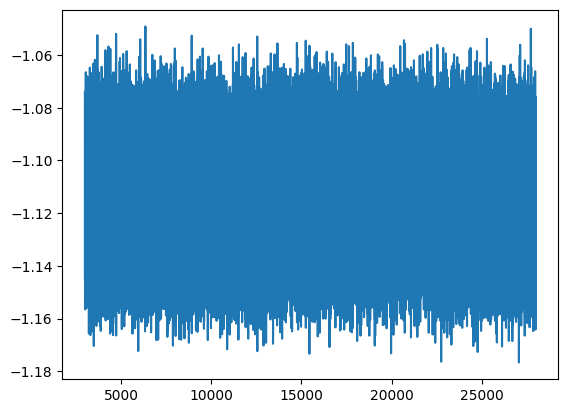

In [150]:
plt.plot(merged_df['time'][0],merged_df['voltage'][0])

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_10986/1033803065.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


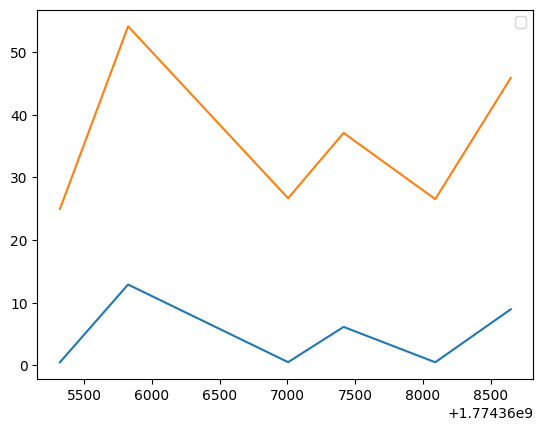

In [111]:
merged_df['means'] = merged_df[['1000.1: CH1 Object', '1000.2: CH2 Object']].mean(axis=1)
merged_df['diff'] = merged_df['1000.2: CH2 Object'] - merged_df['1000.1: CH1 Object']
plt.plot(merged_df['Time'], merged_df['diff'])
plt.plot(merged_df['Time'], merged_df['means'])
plt.legend()
plt.show()


In [148]:
ranged_df = merged_df[(22.5<=merged_df['means']) & (merged_df['means']<27.5)]
diffs = ranged_df['diff'].sort_values()

sorted_ranged_df = ranged_df[diffs.index]

for times, voltages in zip(sorted_ranged_df['time'].items(), sorted_ranged_df['voltage'].items()):
    plt.plot(times,voltages)
plt.legend()
plt.show()


KeyError: "None of [Index([  0,  21,  20,  19,  18,  17,  15,  14,  13,  12,\n       ...\n       144, 145, 146, 147, 148, 149, 150, 151, 153, 154],\n      dtype='int64', length=154)] are in the [columns]"

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_10986/3552191437.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


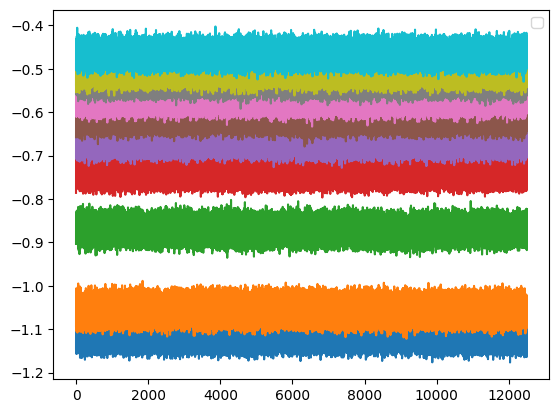

In [147]:

for voltages in ranged_series.values[:10]:
    plt.plot(voltages)
plt.legend()
plt.show()

In [127]:
ranged_series(22.5,25)

0     [-1.1445835383858267, -1.0760531496062993, -1....
1     [-1.0925799704724408, -1.0278604822834647, -1....
2     [-0.9029521407480314, -0.834423597440945, -0.8...
3     [-0.7857898622047245, -0.6824126476377952, -0....
4     [-0.7067322834645668, -0.6281520669291338, -0....
5     [-0.6574944635826773, -0.5869063730314961, -0....
6     [-0.5912746062992126, -0.533863188976378, -0.5...
7     [-0.5562493848425196, -0.4903512549212598, -0....
8     [-0.5359701033464567, -0.48567175196850393, -0...
9     [-0.4990385088582677, -0.43557394192913385, -0...
10    [-0.46801611712598423, -0.39883796751968503, -...
11    [-0.4510328494094488, -0.39294291338582676, -0...
12    [-0.4477417568897638, -0.38063422736220476, -0...
13    [-0.4544937253937008, -0.37023745078740156, -0...
14    [-0.4123757381889764, -0.37111035925196856, -0...
15    [-0.41809301181102365, -0.376138656496063, -0....
16    [-0.3900073818897638, -0.3381717519685039, -0....
17    [-0.41098855807086615, -0.3458040108267716